<a href="https://colab.research.google.com/github/Varalakshmi-skab/datasciencelearning/blob/main/RandomForestRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

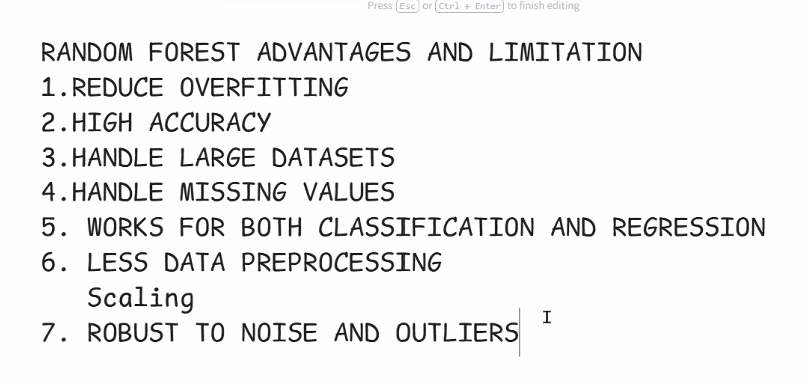

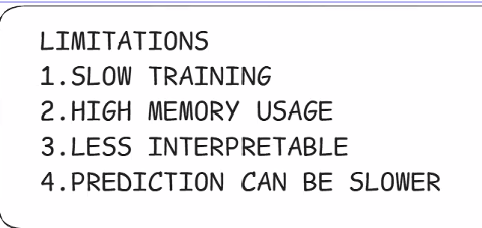

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomTreesEmbedding
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Datasets for datascience/rrandomforest (1).csv")
df.head()

,Area,Bedrooms,Bathrooms,Parking,Age,Location,House_Type,Nearby_School,Furnished,Crime_Rate,Distance_City,Price
0,1460.0,5,1,1,8,Rural,Independent,Yes,Semi,6,12,651.25
1,4372.0,6,4,3,6,Suburban,Villa,Yes,Semi,9,13,1768.20
2,NaN,5,3,3,8,Suburban,Apartment,No,Semi,2,17,1381.67
3,1066.0,3,2,2,17,Suburban,Independent,Yes,NaN,3,17,565.66
4,4044.0,4,1,2,11,Urban,Villa,Yes,Semi,8,36,1568.64


In [ ]:
df.shape

(500, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area           475 non-null    float64
 1   Bedrooms       500 non-null    int64  
 2   Bathrooms      500 non-null    int64  
 3   Parking        500 non-null    int64  
 4   Age            500 non-null    int64  
 5   Location       475 non-null    object 
 6   House_Type     500 non-null    object 
 7   Nearby_School  500 non-null    object 
 8   Furnished      475 non-null    object 
 9   Crime_Rate     500 non-null    int64  
 10  Distance_City  500 non-null    int64  
 11  Price          500 non-null    float64
dtypes: float64(2), int64(6), object(4)
memory usage: 47.0+ KB


In [ ]:
df.isnull().sum()

,0
Area,25
Bedrooms,0
Bathrooms,0
Parking,0
Age,0
Location,25
House_Type,0
Nearby_School,0
Furnished,25
Crime_Rate,0


In [ ]:
df["Area"]=df["Area"].fillna(df["Area"].mean())
df["Location"]=df["Location"].fillna(df["Location"].mode()[0])
df["Furnished"]=df["Furnished"].fillna(df["Furnished"].mode()[0])

In [ ]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Parking,0
Age,0
Location,0
House_Type,0
Nearby_School,0
Furnished,0
Crime_Rate,0


In [ ]:
df

,Area,Bedrooms,Bathrooms,Parking,Age,Location,House_Type,Nearby_School,Furnished,Crime_Rate,Distance_City,Price
0,1460.000000,5,1,1,8,Rural,Independent,Yes,Semi,6,12,651.25
1,4372.000000,6,4,3,6,Suburban,Villa,Yes,Semi,9,13,1768.20
2,2822.850526,5,3,3,8,Suburban,Apartment,No,Semi,2,17,1381.67
3,1066.000000,3,2,2,17,Suburban,Independent,Yes,Semi,3,17,565.66
4,4044.000000,4,1,2,11,Urban,Villa,Yes,Semi,8,36,1568.64
...,...,...,...,...,...,...,...,...,...,...,...,...
495,1528.000000,4,2,2,4,Urban,Independent,Yes,No,2,12,829.82
496,733.000000,4,3,2,3,Suburban,Apartment,Yes,Semi,10,38,417.89
497,2705.000000,5,3,1,17,Urban,Villa,Yes,Semi,8,13,1245.25
498,4227.000000,5,1,0,23,Urban,Apartment,Yes,Fully,7,29,1517.32


In [ ]:
le=LabelEncoder()
df["Location"]=le.fit_transform(df["Location"])
df["House_Type"]=le.fit_transform(df["House_Type"])
df["Nearby_School"]=le.fit_transform(df["Nearby_School"])
df["Furnished"]=le.fit_transform(df["Furnished"])

In [ ]:
df

,Area,Bedrooms,Bathrooms,Parking,Age,Location,House_Type,Nearby_School,Furnished,Crime_Rate,Distance_City,Price
0,1460.000000,5,1,1,8,0,1,1,2,6,12,651.25
1,4372.000000,6,4,3,6,1,2,1,2,9,13,1768.20
2,2822.850526,5,3,3,8,1,0,0,2,2,17,1381.67
3,1066.000000,3,2,2,17,1,1,1,2,3,17,565.66
4,4044.000000,4,1,2,11,2,2,1,2,8,36,1568.64
...,...,...,...,...,...,...,...,...,...,...,...,...
495,1528.000000,4,2,2,4,2,1,1,1,2,12,829.82
496,733.000000,4,3,2,3,1,0,1,2,10,38,417.89
497,2705.000000,5,3,1,17,2,2,1,2,8,13,1245.25
498,4227.000000,5,1,0,23,2,0,1,0,7,29,1517.32


In [ ]:
X=df.drop("Price",axis=1)
Y=df["Price"]

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(400, 11)
(100, 11)
(400,)
(100,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf.fit(X_train,Y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred=rf.predict(X_test)

In [ ]:
y_pred

array([1434.4103, 1545.3722, 1524.5721,  748.0789, 1386.6834, 1743.7216,
       1638.2198, 1214.5777,  679.2359,  918.315 ,  754.9755, 1109.149 ,
       1292.9201, 1402.5662,  835.4365,  747.0272,  821.7257, 1489.3681,
        822.9522,  691.9847,  535.2384,  834.3444,  620.4313, 1140.9311,
        985.0823,  873.0235, 1208.5883, 1375.7632, 1094.5183,  602.6468,
        733.7117, 1360.703 , 1123.8886,  513.7547, 1152.4834,  930.7516,
       1578.9523,  549.4609,  566.3773, 1642.5417, 1212.5359,  764.4405,
        820.6942, 1474.7311, 1293.7277, 1274.2257,  733.5611,  966.961 ,
       1478.2447,  915.1263, 1096.1787, 1348.4029, 1536.6666,  981.2516,
       1752.6508, 1261.6672,  960.3567, 1294.0873, 1668.5976,  880.0561,
        697.4704, 1056.7891,  985.5946,  505.3818,  553.774 , 1099.4814,
        801.8688, 1634.577 ,  515.9851,  597.2851,  978.7408, 1412.705 ,
       1459.3573,  767.1678, 1391.1625, 1283.7262, 1610.74  , 1742.1247,
       1131.1355, 1660.6965, 1779.5909, 1379.9381, 

In [ ]:
r2score=r2_score(Y_test,y_pred)
r2score

0.9010444787685787

In [ ]:
mae=mean_absolute_error(Y_test,y_pred)
print("Mean Absolute Error",mae)

Mean Absolute Error 75.34334700000004


In [ ]:
mse=mean_squared_error(Y_test,y_pred)
print("Mean Squared Error",mse)

Mean Squared Error 13670.211237821302


In [ ]:
rmse=np.sqrt(mse)
print("Root Mean Squared Error",rmse)

Root Mean Squared Error 116.91967857388808


#**Grid Search CV**

*  Grid Search CV is a technique used to find the best hyperparameters automatically for a ML model




In [ ]:
from sklearn.model_selection import GridSearchCV
paramgrid={
    "n_estimators":[50,100,150],
    "max_depth":[5,10,15]
}

In [ ]:
grid=GridSearchCV(
    RandomForestRegressor(random_state=42),
    paramgrid,
    scoring="r2"
)
grid.fit(X_train,Y_train)

GridSearchCV(estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [50, 100, 150]},
             scoring='r2')

In [ ]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 15, 'n_estimators': 150}
0.89102008073434
